In [73]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

plt.style.use('fivethirtyeight')
%matplotlib inline

sns.set_palette("deep", desat=.6)
sns.set_context(rc={"figure.figsize": (12, 4)})

# --- Metricas ---
def mae(targets, predictions) -> float:
    error = predictions - targets
    return round(np.abs(error).mean(), 4)

def mse(targets, predictions) -> float:
    error = predictions - targets
    return round((error ** 2).mean(), 4)

def rmse(targets, predictions) -> float:
    error = predictions - targets
    return round(np.sqrt((error ** 2).mean()), 4)

def mape(targets, predictions) -> float:
    error = predictions - targets
    if any(x == 0 for x in targets):
        return np.inf
    else:
        return round(np.abs(error / targets).mean(), 4)

def maape(targets, predictions) -> float:
    error = predictions - targets
    if any((x, y) == (0, 0) for x, y in zip(predictions, targets)):
        return np.inf
    else:
        return round(np.arctan(np.abs(error / targets)).mean(), 4)

def wmape(targets, predictions) -> float:
    error = predictions - targets
    sum_values = np.sum(targets)
    if sum_values == 0:
        return np.inf
    else:
        return round(np.abs(error).sum() / sum_values, 4)

def mmape(targets, predictions) -> float:
    error = np.abs(predictions - targets)
    denom = 1 + np.abs(targets)
    return round(np.mean(error / denom), 4)

def smape(targets, predictions) -> float:
    error = predictions - targets
    sum_values = np.abs(predictions) + np.abs(targets)
    if any(x == 0 for x in sum_values):
        return np.inf
    else:
        return round(2 * np.mean(np.abs(error) / sum_values), 4)

def summary_metrics(df) -> pd.DataFrame:
    df_result = pd.DataFrame()
    y_true = df['y']
    y_pred = df['yhat']
    df_result['mae'] = [round(mae(y_true, y_pred), 4)]
    df_result['mse'] = [round(mse(y_true, y_pred), 4)]
    df_result['rmse'] = [round(rmse(y_true, y_pred), 4)]
    df_result['mape'] = [round(mape(y_true, y_pred), 4)]
    df_result['maape'] = [round(maape(y_true, y_pred), 4)]
    df_result['wmape'] = [round(wmape(y_true, y_pred), 4)]
    df_result['mmape'] = [round(mmape(y_true, y_pred), 4)]
    df_result['smape'] = [round(smape(y_true, y_pred), 4)]
    return df_result

# --- Carga de datos ---
validate_categorie = [
    'Introduction', 'Méfait', 'Vol dans / sur véhicule à moteur', 'Vol de véhicule à moteur',
]

df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/interventionscitoyendo.csv", sep=",", encoding='latin-1')
df.columns = df.columns.str.lower()
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

df = df.loc[lambda x: x['categorie'].isin(validate_categorie)]
df = df.sort_values(['categorie', 'date'])
df.head()

# --- Series temporales semanales por categoria ---
cols = ['date', 'pdq']
y_s1 = df.loc[lambda x: x.categorie == validate_categorie[0]][cols].set_index('date').resample('W').mean()
y_s2 = df.loc[lambda x: x.categorie == validate_categorie[1]][cols].set_index('date').resample('W').mean()
y_s3 = df.loc[lambda x: x.categorie == validate_categorie[2]][cols].set_index('date').resample('W').mean()
y_s4 = df.loc[lambda x: x.categorie == validate_categorie[3]][cols].set_index('date').resample('W').mean()

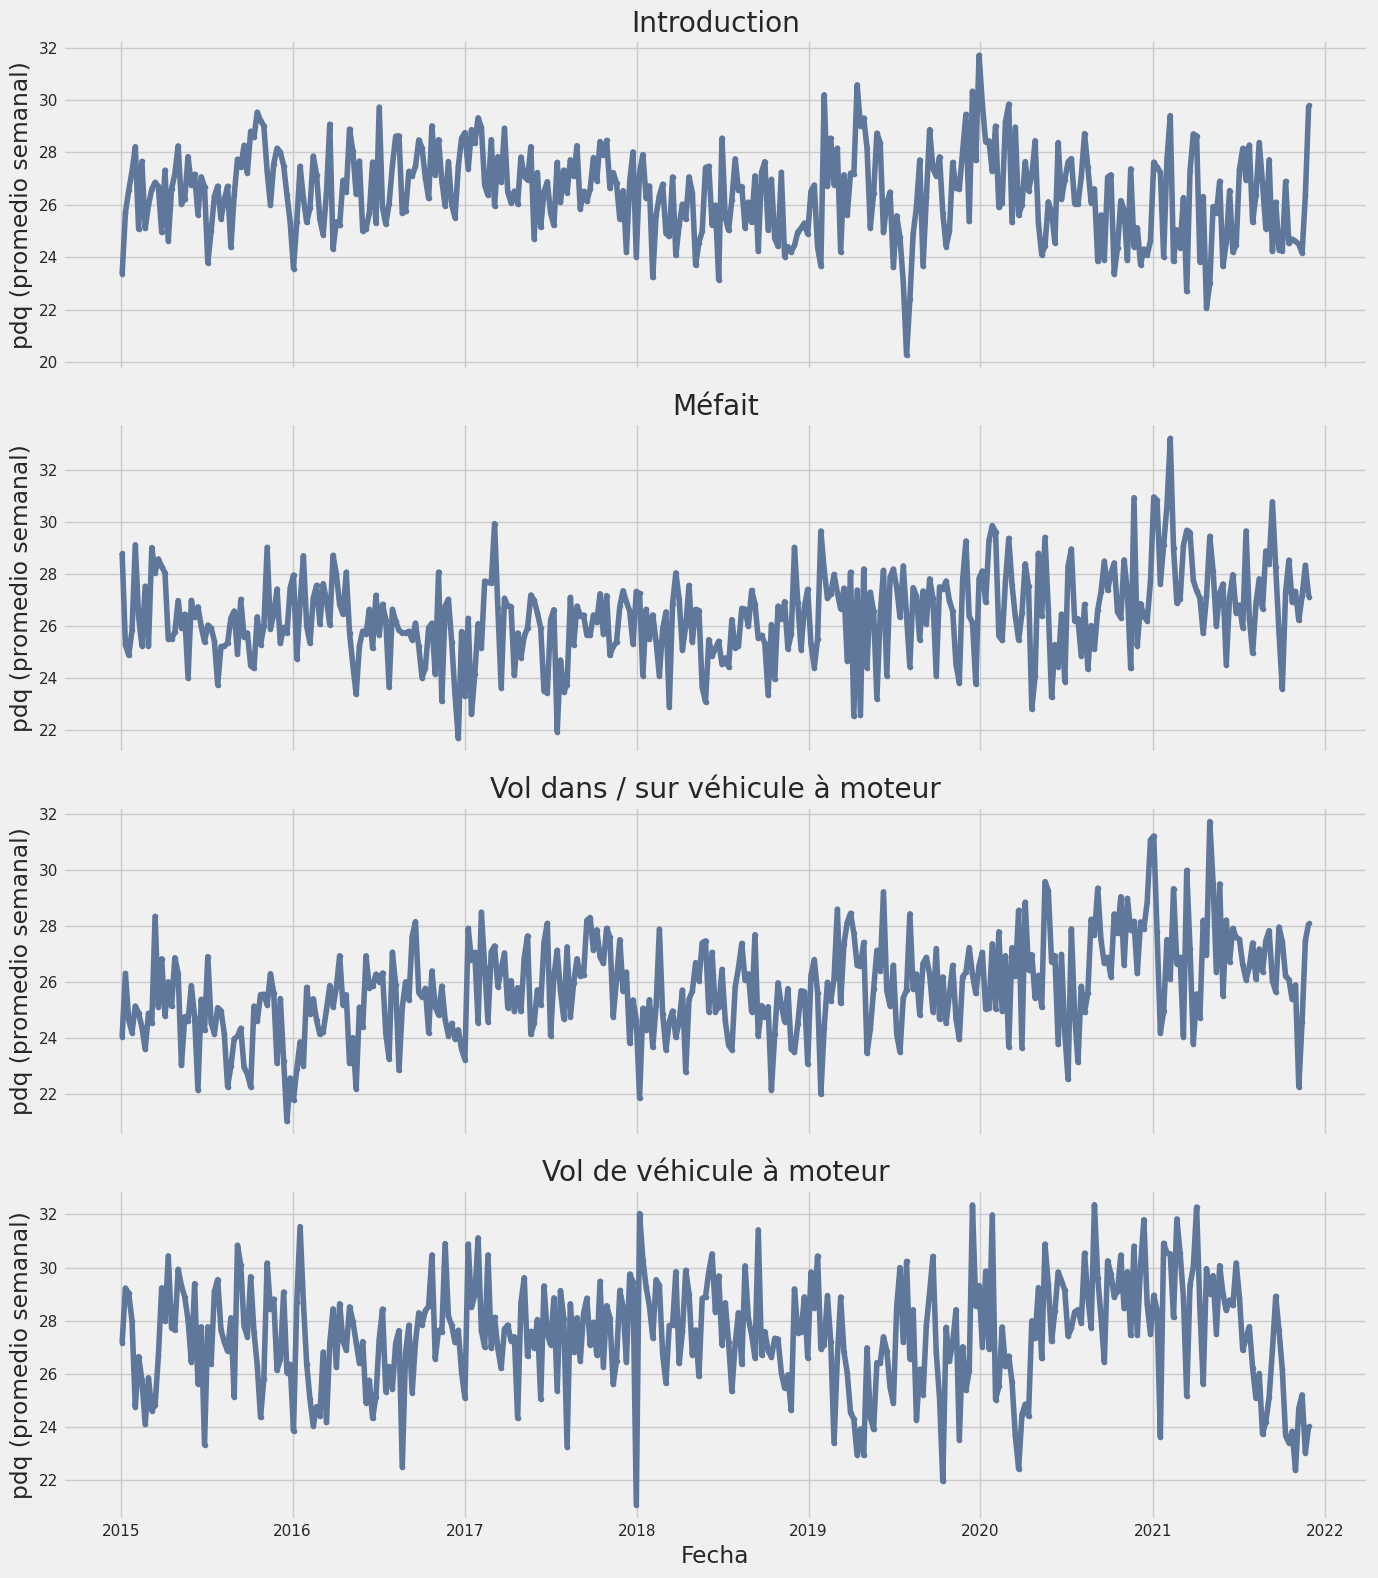

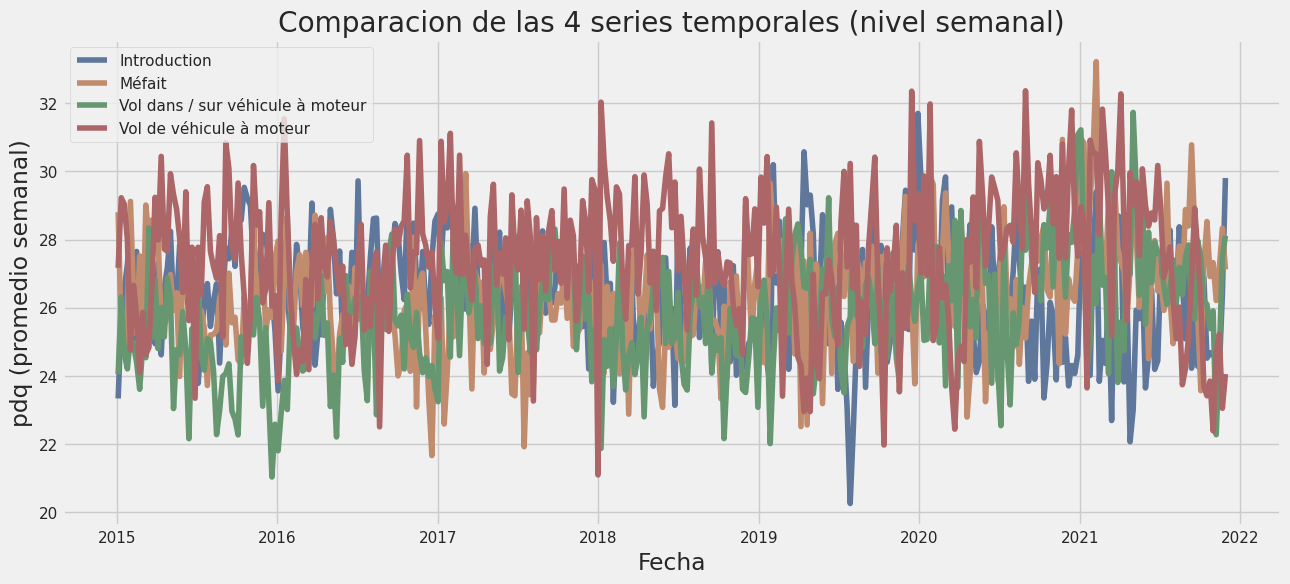

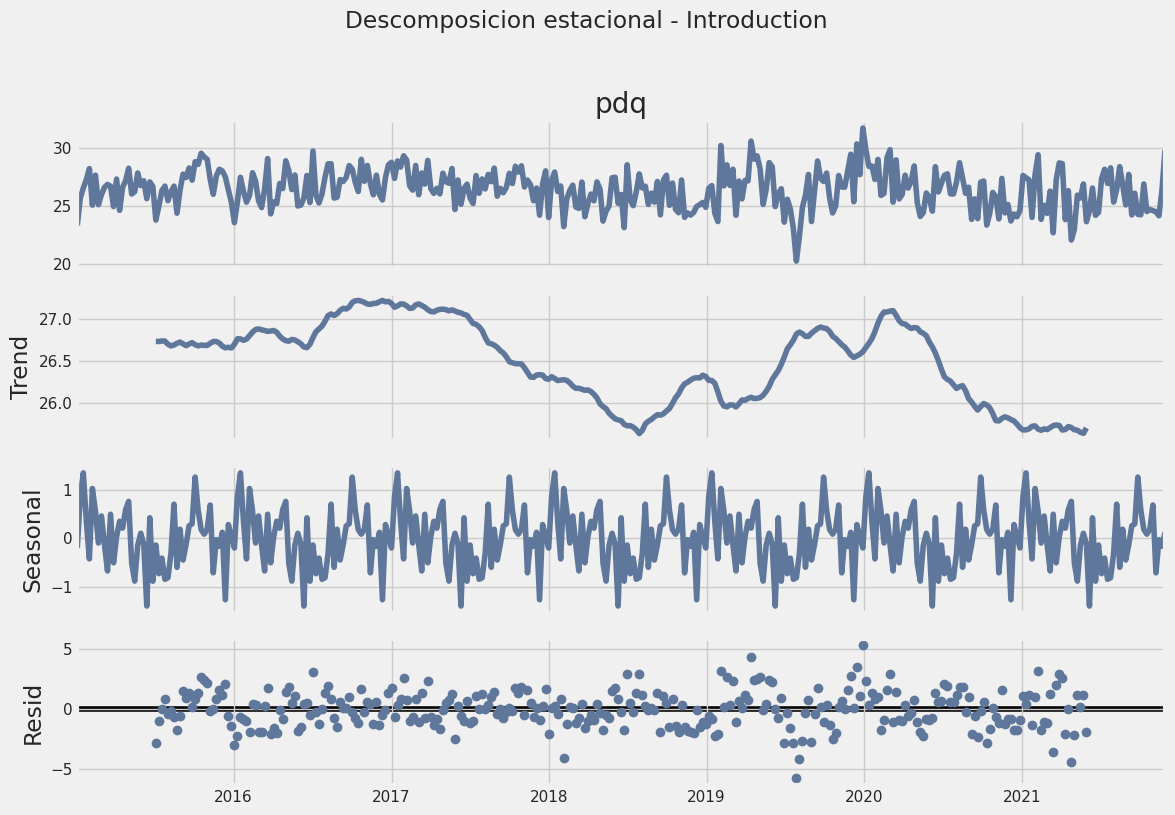

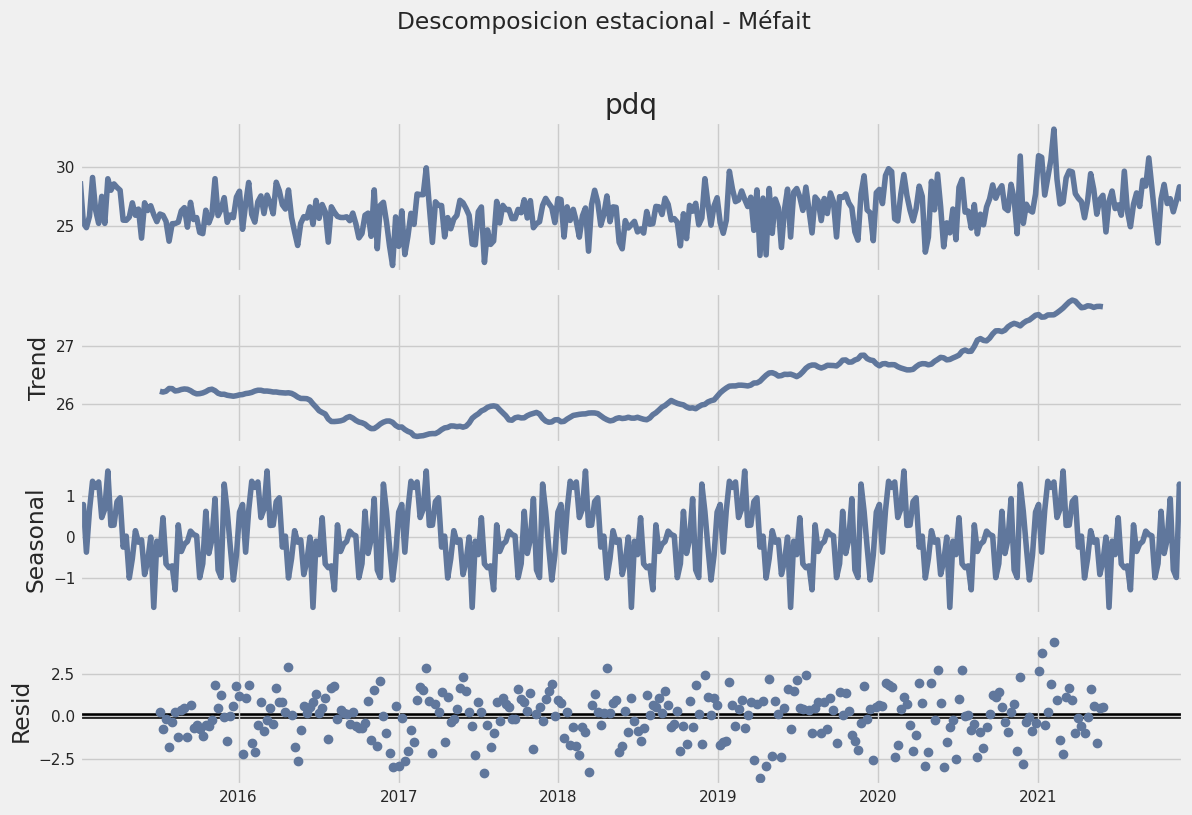

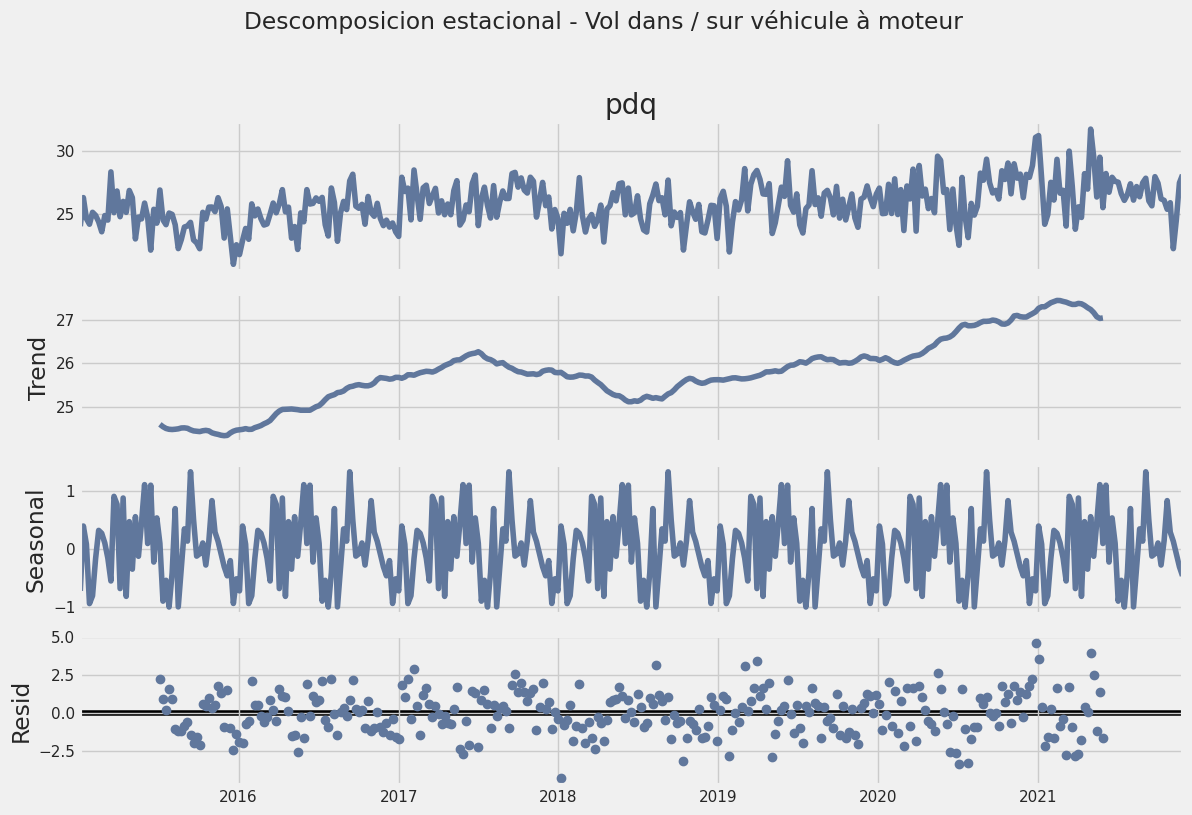

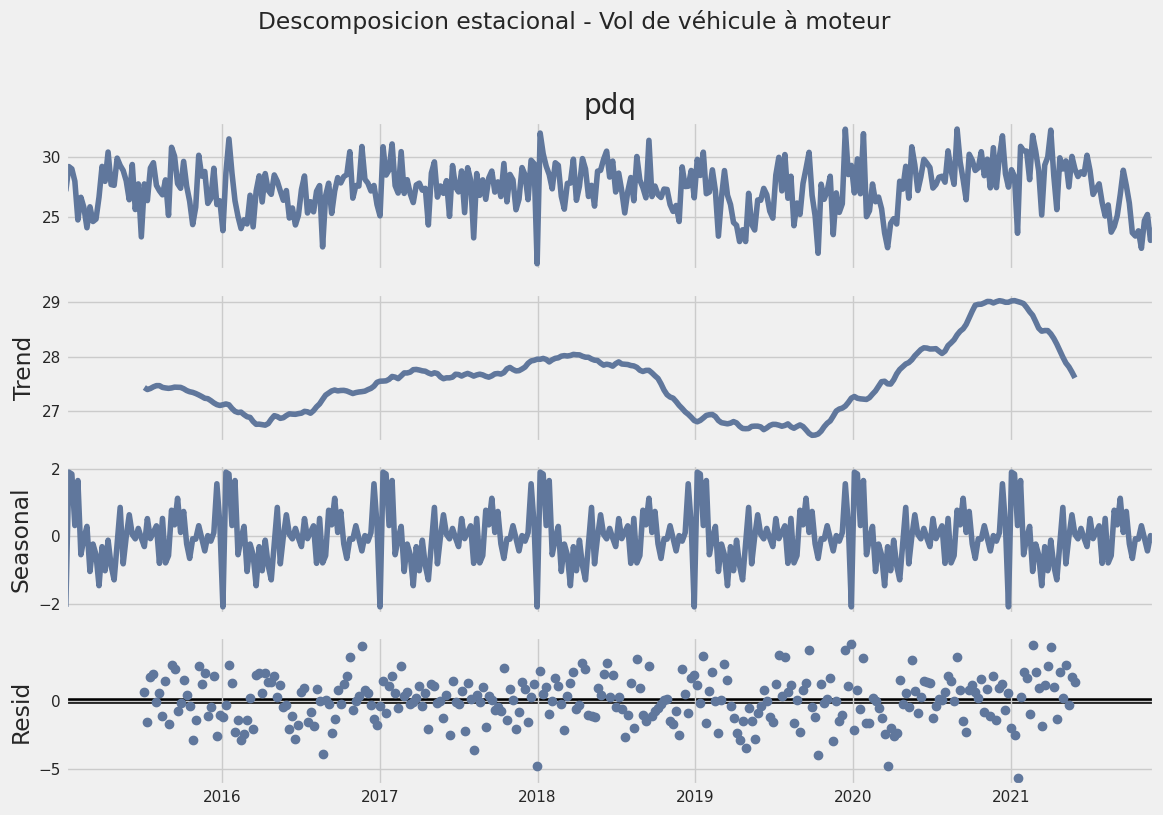

In [74]:
# ============================================================
# 1. Visualizar las series temporales y_s1, y_s2, y_s3, y_s4
# ============================================================
series_dict = {
    validate_categorie[0]: y_s1,
    validate_categorie[1]: y_s2,
    validate_categorie[2]: y_s3,
    validate_categorie[3]: y_s4,
}

fig, axs = plt.subplots(4, 1, figsize=(14, 16), sharex=True)
for ax, (nombre, serie) in zip(axs, series_dict.items()):
    ax.plot(serie.index, serie['pdq'], marker='o', markersize=3)
    ax.set_title(nombre)
    ax.set_ylabel('pdq (promedio semanal)')
plt.xlabel('Fecha')
plt.tight_layout()
plt.show()

# Todas juntas para comparar magnitud/escala
plt.figure(figsize=(14, 6))
for nombre, serie in series_dict.items():
    plt.plot(serie.index, serie['pdq'], label=nombre)
plt.legend()
plt.title('Comparacion de las 4 series temporales (nivel semanal)')
plt.xlabel('Fecha'); plt.ylabel('pdq (promedio semanal)')
plt.show()

# Descomposicion estacional (tendencia, estacionalidad, residuo) de cada serie
from statsmodels.tsa.seasonal import seasonal_decompose

for nombre, serie in series_dict.items():
    serie_interp = serie['pdq'].interpolate()
    decomposicion = seasonal_decompose(serie_interp, model='additive', period=52)
    fig = decomposicion.plot()
    fig.set_size_inches(12, 8)
    fig.suptitle(f'Descomposicion estacional - {nombre}', y=1.02)
    plt.tight_layout()
    plt.show()

# Observaciones:
# - Las 4 series muestran fluctuaciones semanales con posibles patrones estacionales
#   anuales (mas o menos incidentes segun la epoca del año).
# - Algunas categorias (ej. "Vol dans / sur véhicule à moteur") presentan mayor
#   magnitud y variabilidad que otras (ej. "Introduction"), lo que sugiere que cada
#   serie debe modelarse de forma independiente.
# - La descomposicion permite separar tendencia (aumento/disminucion sostenida en
#   el tiempo), estacionalidad (patron que se repite cada cierto periodo, ej. 52
#   semanas) y el componente residual (ruido no explicado).

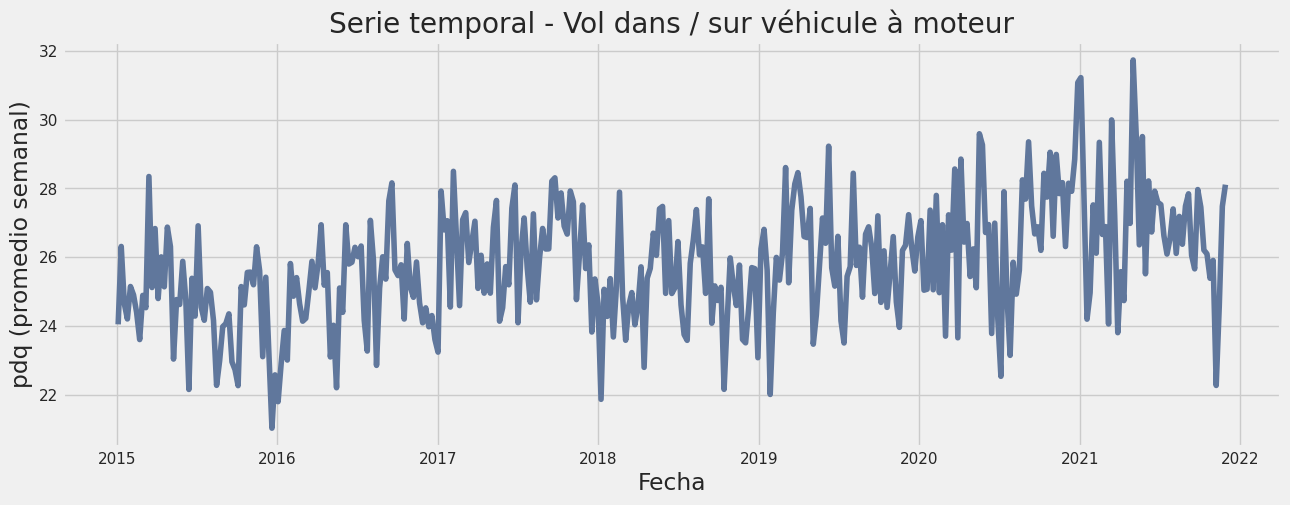

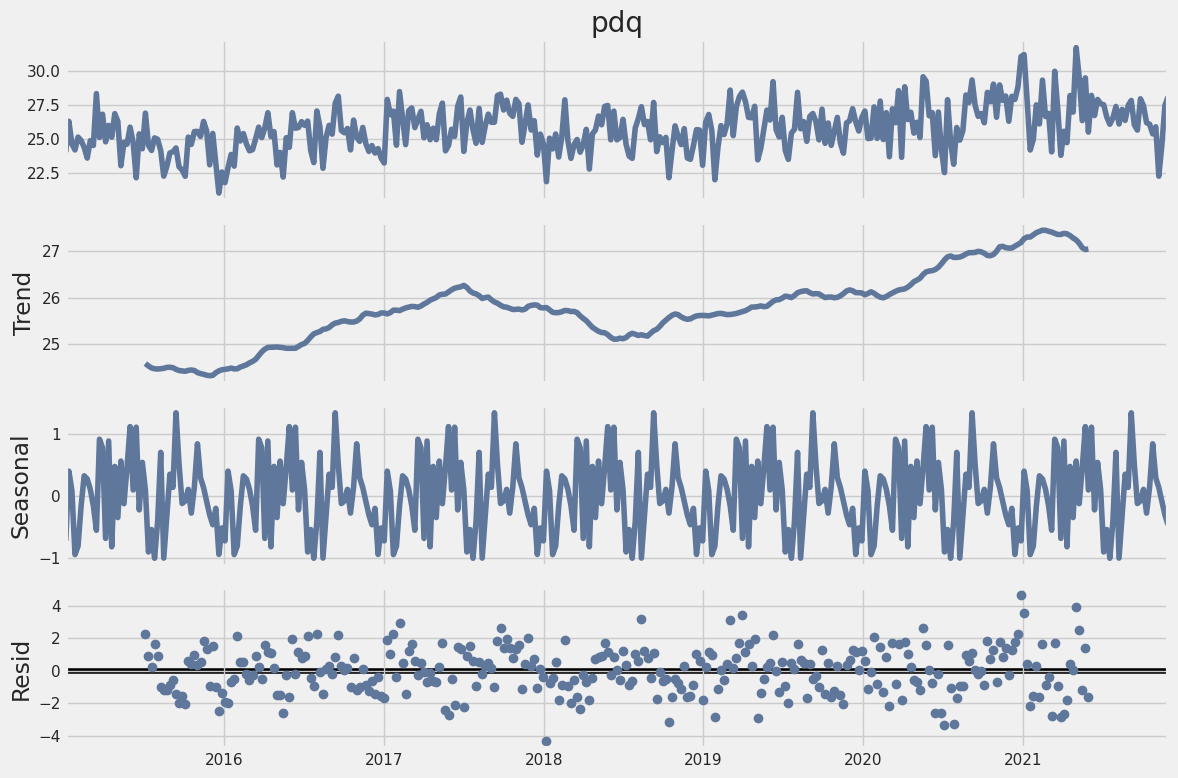

ADF Statistic: -5.7429
p-value: 0.0000
La serie es estacionaria


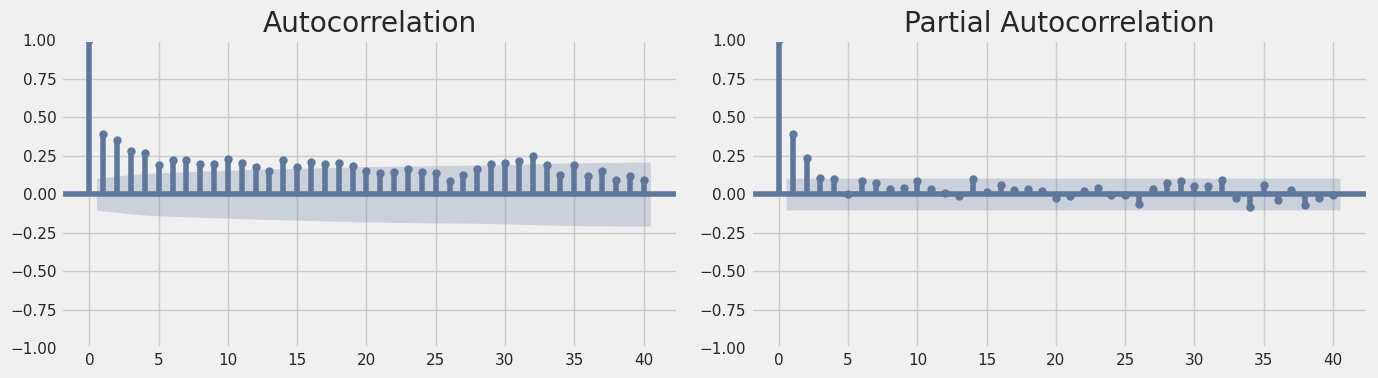

       mae     mse    rmse    mape   maape   wmape   mmape   smape  \
37  1.3657  3.1739  1.7815  0.0511  0.0509  0.0508  0.0492  0.0508   
13  1.3788  3.2506  1.8029  0.0515  0.0513  0.0513  0.0497  0.0513   
45  1.3777  3.2973  1.8158  0.0519  0.0517  0.0512  0.0500  0.0512   
11  1.3671  3.3476  1.8296  0.0500  0.0499  0.0508  0.0483  0.0508   
15  1.3671  3.3476  1.8297  0.0501  0.0499  0.0508  0.0483  0.0508   
35  1.3819  3.3677  1.8351  0.0505  0.0503  0.0514  0.0487  0.0514   
39  1.3819  3.3678  1.8352  0.0505  0.0503  0.0514  0.0487  0.0514   
5   1.3947  3.3855  1.8400  0.0520  0.0518  0.0519  0.0501  0.0518   
7   1.3633  3.4296  1.8519  0.0500  0.0499  0.0507  0.0482  0.0507   
3   1.3695  3.4389  1.8544  0.0502  0.0500  0.0509  0.0484  0.0509   

                        model  
37  SARIMA_(1,0,0)X(1,0,1,12)  
13  SARIMA_(0,0,1)X(1,0,1,12)  
45  SARIMA_(1,0,1)X(1,0,1,12)  
11  SARIMA_(0,0,1)X(0,1,1,12)  
15  SARIMA_(0,0,1)X(1,1,1,12)  
35  SARIMA_(1,0,0)X(0,1,1,12)  
39  S

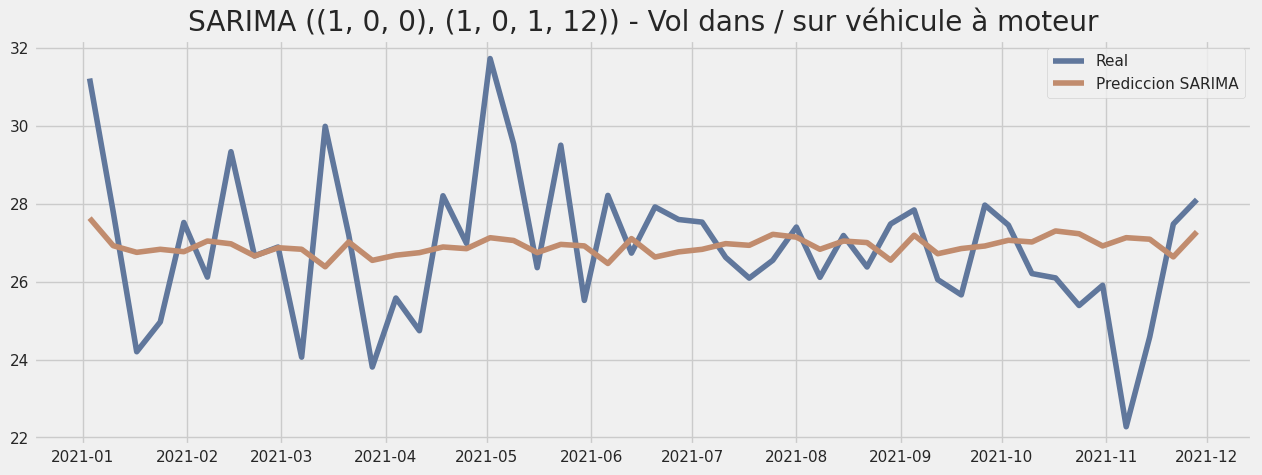

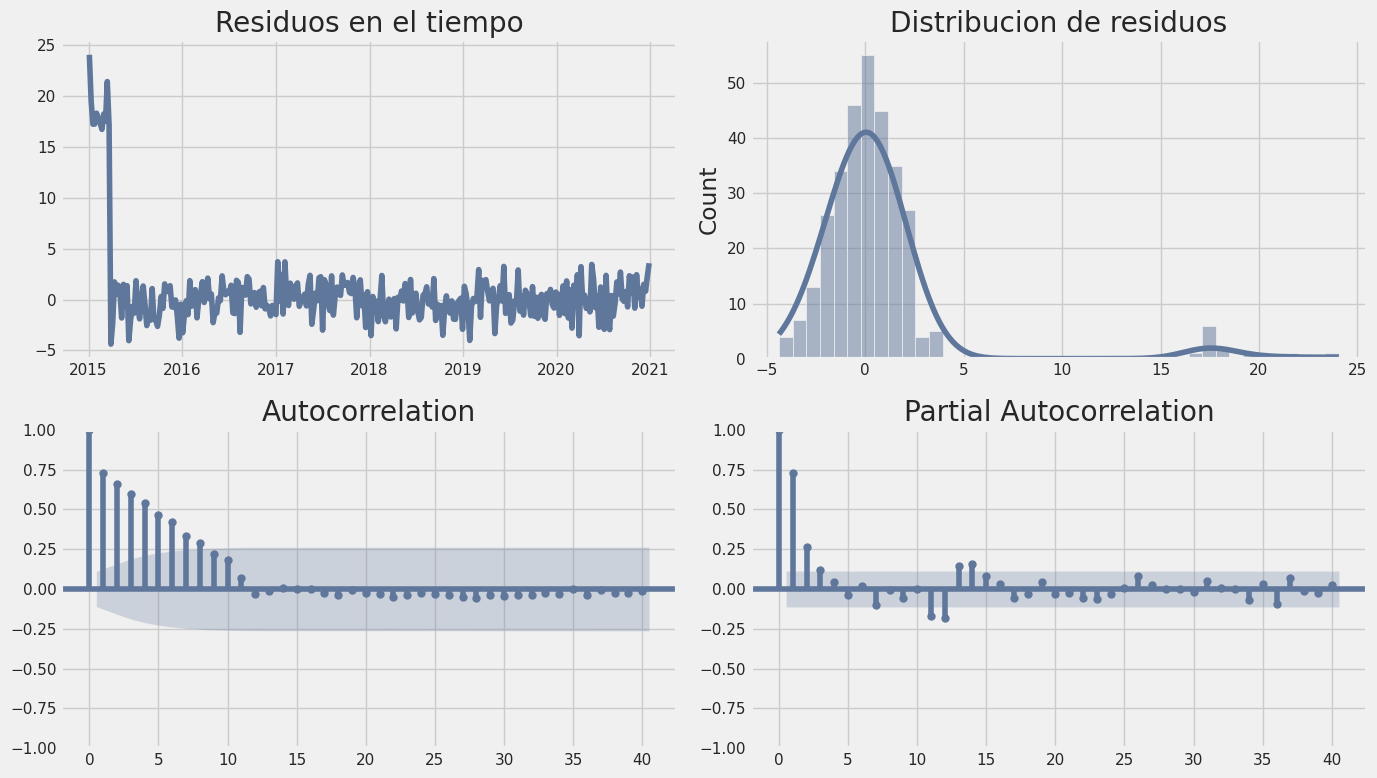


Test de Ljung-Box (H0: los residuos son ruido blanco):
       lb_stat      lb_pvalue
10  730.277349  1.980064e-150
20  733.285429  1.987376e-142


In [75]:
# ============================================================
# 2. Analisis exploratorio + Modelado SARIMA (serie seleccionada)
# ============================================================
# Se selecciona la serie 'Vol dans / sur véhicule à moteur' (y_s3)
serie_nombre = validate_categorie[2]
y = y_s3.copy()
y['pdq'] = y['pdq'].interpolate()  # rellenar posibles semanas sin datos

# --- Analisis exploratorio ---
plt.figure(figsize=(14, 5))
plt.plot(y.index, y['pdq'])
plt.title(f'Serie temporal - {serie_nombre}')
plt.xlabel('Fecha'); plt.ylabel('pdq (promedio semanal)')
plt.show()

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

decomposicion = seasonal_decompose(y['pdq'], model='additive', period=52)
fig = decomposicion.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

# Test de estacionariedad (Dickey-Fuller)
adf_result = adfuller(y['pdq'])
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("La serie es estacionaria" if adf_result[1] < 0.05 else "La serie NO es estacionaria (requiere diferenciacion)")

fig, axs = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y['pdq'], ax=axs[0], lags=40)
plot_pacf(y['pdq'], ax=axs[1], lags=40)
plt.tight_layout()
plt.show()

# --- Modelado SARIMA ---
class SarimaModels:
    def __init__(self, params):
        self.params = params

    @property
    def name_model(self):
        return f"SARIMA_{self.params[0]}X{self.params[1]}".replace(' ', '')

    @staticmethod
    def test_train_model(y, date):
        mask_ds = y.index < date
        y_train = y[mask_ds]
        y_test = y[~mask_ds]
        return y_train, y_test

    def fit_model(self, y, date):
        y_train, y_test = self.test_train_model(y, date)
        model = SARIMAX(y_train, order=self.params[0], seasonal_order=self.params[1],
                         enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit(disp=0)
        return model_fit

    def df_testig(self, y, date):
        y_train, y_test = self.test_train_model(y, date)
        model = SARIMAX(y_train, order=self.params[0], seasonal_order=self.params[1],
                         enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit(disp=0)

        start_index = y_test.index.min()
        end_index = y_test.index.max()
        preds = model_fit.get_prediction(start=start_index, end=end_index, dynamic=False)
        df_temp = pd.DataFrame({'y': y_test['pdq'], 'yhat': preds.predicted_mean})
        return df_temp

    def metrics(self, y, date):
        df_temp = self.df_testig(y, date)
        df_metrics = summary_metrics(df_temp)
        df_metrics['model'] = self.name_model
        return df_metrics

import itertools

p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]
params = list(itertools.product(pdq, seasonal_pdq))
target_date = '2021-01-01'

# Grid search: probar todas las combinaciones y quedarse con la de menor RMSE
resultados_sarima = []

for par in params:
    try:
        sm_model = SarimaModels(par)
        metrics_df = sm_model.metrics(y, target_date)
        resultados_sarima.append(metrics_df)
    except Exception:
        continue

df_resultados_sarima = pd.concat(resultados_sarima, ignore_index=True)
df_resultados_sarima = df_resultados_sarima.sort_values('rmse')
print(df_resultados_sarima.head(10))

mejores_params_idx = df_resultados_sarima.index[0]
mejores_params = params[mejores_params_idx]
print("\nMejor configuracion SARIMA:", mejores_params)

# Ajustar el mejor modelo y obtener predicciones/residuos
mejor_sarima = SarimaModels(mejores_params)
model_fit_sarima = mejor_sarima.fit_model(y, target_date)
df_test_sarima = mejor_sarima.df_testig(y, target_date)
metricas_sarima = mejor_sarima.metrics(y, target_date)
print("\nMetricas del mejor modelo SARIMA:")
print(metricas_sarima)

# Prediccion vs real
plt.figure(figsize=(14, 5))
plt.plot(df_test_sarima.index, df_test_sarima['y'], label='Real')
plt.plot(df_test_sarima.index, df_test_sarima['yhat'], label='Prediccion SARIMA')
plt.legend()
plt.title(f'SARIMA {mejores_params} - {serie_nombre}')
plt.show()

# --- Validacion de residuos (ruido blanco) ---
residuos = model_fit_sarima.resid

fig, axs = plt.subplots(2, 2, figsize=(14, 8))
axs[0, 0].plot(residuos)
axs[0, 0].set_title('Residuos en el tiempo')
sns.histplot(residuos, kde=True, ax=axs[0, 1])
axs[0, 1].set_title('Distribucion de residuos')
plot_acf(residuos, ax=axs[1, 0], lags=40)
plot_pacf(residuos, ax=axs[1, 1], lags=40)
plt.tight_layout()
plt.show()

from statsmodels.stats.diagnostic import acorr_ljungbox
ljung_box = acorr_ljungbox(residuos, lags=[10, 20], return_df=True)
print("\nTest de Ljung-Box (H0: los residuos son ruido blanco):")
print(ljung_box)

# Conclusion:
# - Si los p-values del test de Ljung-Box son > 0.05, no se rechaza H0 y se
#   concluye que los residuos se comportan como ruido blanco (no queda
#   estructura/autocorrelacion por explicar), lo que indica un buen ajuste
#   del modelo SARIMA seleccionado.
# - El grafico ACF/PACF de los residuos sin picos significativos fuera de la
#   banda de confianza confirma este comportamiento.

Metricas Prophet:
      mae     mse    rmse    mape   maape   wmape   mmape   smape    model
0  1.5929  4.4892  2.1188  0.0609  0.0605  0.0592  0.0586  0.0589  Prophet


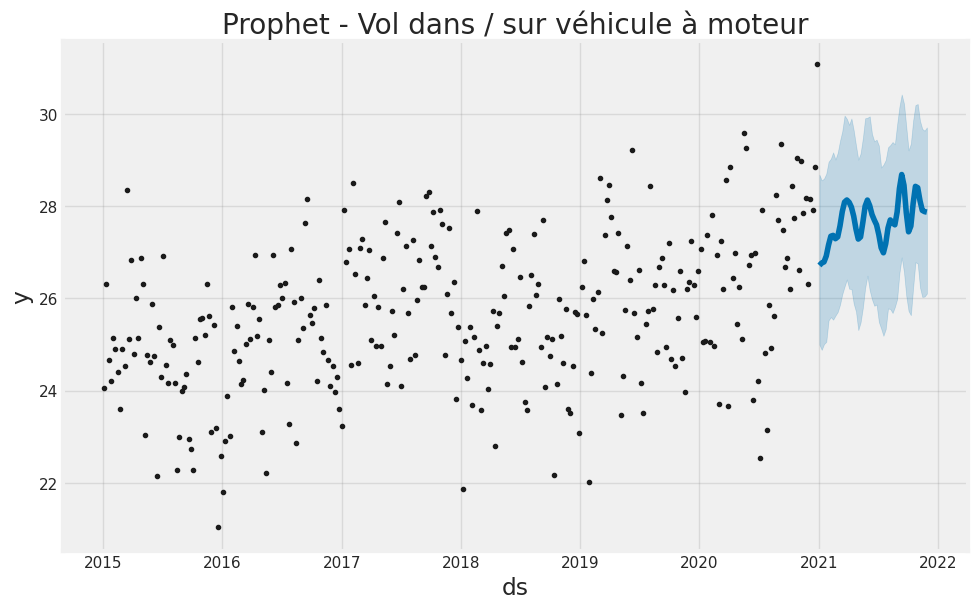

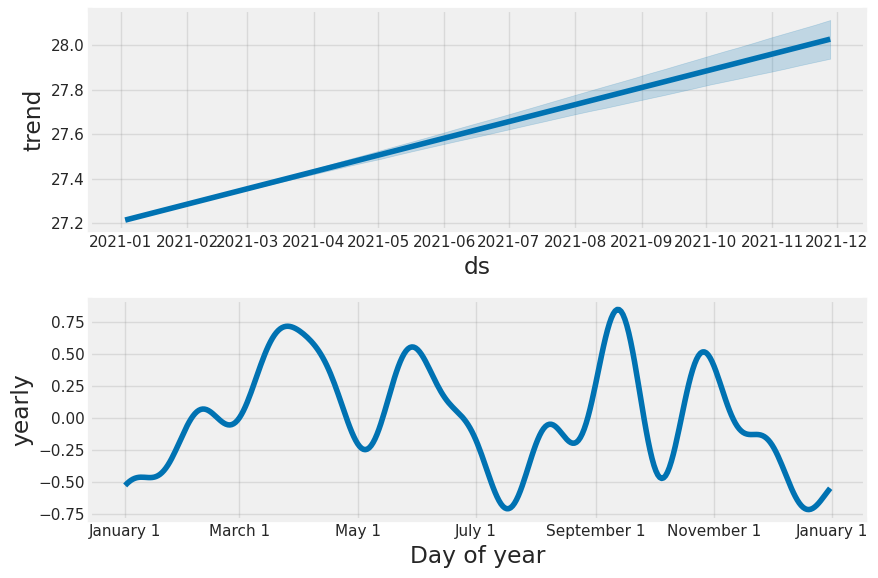


Comparacion de metricas SARIMA vs Prophet:
                       model     mae     mse    rmse    mape   smape
0  SARIMA_(1,0,0)X(1,0,1,12)  1.3657  3.1739  1.7815  0.0511  0.0508
1                    Prophet  1.5929  4.4892  2.1188  0.0609  0.0589


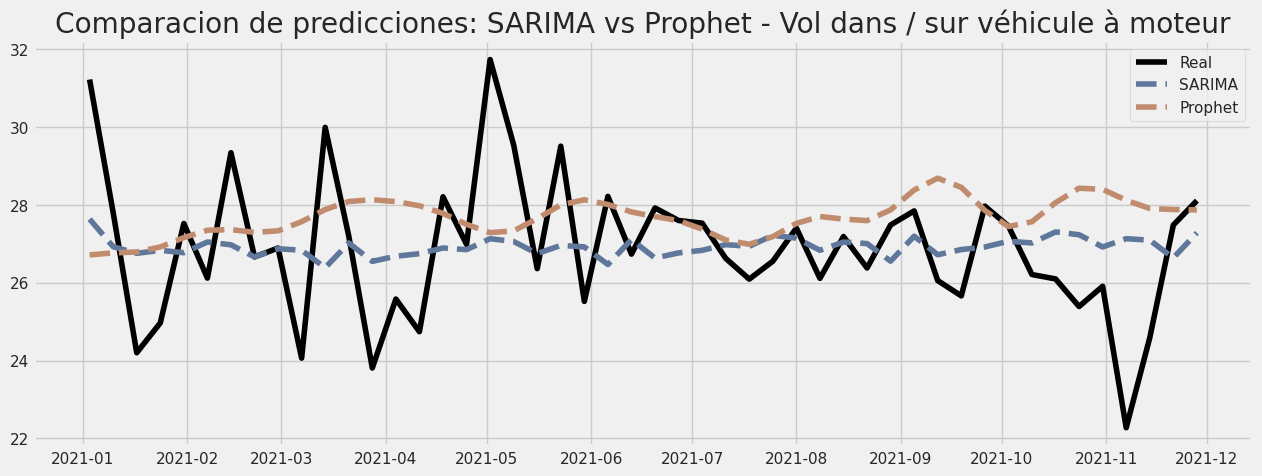


Modelo elegido: SARIMA_(1,0,0)X(1,0,1,12)


In [76]:
# ============================================================
# 3. Modelado con Prophet y comparacion con SARIMA
# ============================================================
!pip install prophet -q
from prophet import Prophet

# Prophet requiere columnas 'ds' (fecha) e 'y' (valor)
df_prophet = y.reset_index().rename(columns={'date': 'ds', 'pdq': 'y'})

y_train_p = df_prophet[df_prophet['ds'] < target_date]
y_test_p = df_prophet[df_prophet['ds'] >= target_date]

modelo_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
modelo_prophet.fit(y_train_p)

# Prediccion sobre el periodo de test
future = y_test_p[['ds']]
forecast = modelo_prophet.predict(future)

df_test_prophet = pd.DataFrame({
    'y': y_test_p['y'].values,
    'yhat': forecast['yhat'].values
}, index=y_test_p['ds'].values)

metricas_prophet = summary_metrics(df_test_prophet)
metricas_prophet['model'] = 'Prophet'
print("Metricas Prophet:")
print(metricas_prophet)

# Grafico de la prediccion de Prophet
fig1 = modelo_prophet.plot(pd.concat([forecast]))
plt.title(f'Prophet - {serie_nombre}')
plt.show()

fig2 = modelo_prophet.plot_components(forecast)
plt.show()

# --- Comparacion SARIMA vs Prophet ---
df_comparacion = pd.concat([metricas_sarima, metricas_prophet], ignore_index=True)
df_comparacion = df_comparacion[['model', 'mae', 'mse', 'rmse', 'mape', 'smape']]
print("\nComparacion de metricas SARIMA vs Prophet:")
print(df_comparacion)

plt.figure(figsize=(14, 5))
plt.plot(df_test_sarima.index, df_test_sarima['y'], label='Real', color='black')
plt.plot(df_test_sarima.index, df_test_sarima['yhat'], label='SARIMA', linestyle='--')
plt.plot(df_test_prophet.index, df_test_prophet['yhat'], label='Prophet', linestyle='--')
plt.legend()
plt.title(f'Comparacion de predicciones: SARIMA vs Prophet - {serie_nombre}')
plt.show()

# Conclusiones:
# - SARIMA requiere identificar manualmente (o mediante grid search) los ordenes
#   (p,d,q)(P,D,Q,S), y asume una estructura lineal y estacionaria (tras
#   diferenciacion) de la serie; es sensible a la correcta especificacion de la
#   estacionalidad.
# - Prophet, en cambio, esta diseñado para ser mas automatico y robusto ante
#   datos faltantes, outliers y cambios de tendencia, descomponiendo la serie en
#   tendencia + estacionalidad + eventos especiales, sin requerir una eleccion
#   manual tan fina de hiperparametros.
# - Segun las metricas de la tabla de comparacion, el modelo con menor
#   MAE/RMSE/MAPE es preferible para esta serie en particular.
# - En general, SARIMA suele ser preferible cuando se dispone de una serie
#   relativamente corta, estacionaria o facilmente transformable, y se busca
#   un modelo estadistico interpretable con fundamentos teoricos solidos.
#   Prophet suele ser preferible cuando la serie es larga, tiene multiples
#   estacionalidades, datos faltantes, o cuando se prioriza facilidad de uso
#   e implementacion rapida por sobre el control fino de los parametros.
print("\nModelo elegido:", df_comparacion.sort_values('rmse').iloc[0]['model'])